# Stage 05a: Initial Model Training

**Purpose:** Quick validation with default hyperparameters

**Inputs:**
- data/04c_train_encoded.parquet
- data/04c_test_encoded.parquet
- data/04c_train_base_margin.parquet
- data/04c_test_base_margin.parquet
- config_generated/04c_monotonicity_constraints.yaml

**Outputs:**
- models/05a_model_initial.json
- results/05a_predictions_train.parquet
- results/05a_predictions_test.parquet
- results/05a_metrics.yaml

In [1]:
config_path = "config/car_coll/v1"

In [2]:
# Parameters
config_path = "config/car_liab/v1"


In [3]:
import matplotlib
matplotlib.use("Agg")

import pandas as pd
import numpy as np
import xgboost as xgb
import yaml, os, sys
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

sys.path.insert(0, str(Path.cwd() / "lib"))
from utils import setup_notebook_environment

print("########################################")
print("# STAGE 05a: INITIAL MODEL TRAINING")
print("########################################")

project_root = setup_notebook_environment()

########################################
# STAGE 05a: INITIAL MODEL TRAINING
########################################


In [4]:
print(f"Python: {sys.version}")
print(f"XGBoost: {xgb.__version__}")

Python: 3.11.15 (main, Jun 11 2026, 15:14:57) [Clang 20.1.8 ]
XGBoost: 3.1.1


In [5]:
# Get machine config
pc_num = open("current.pc").read().strip()
pc_id = f"PC{pc_num}"

config_file = f"{config_path}/config.yaml"
with open(config_file, "r") as f:
    cfg = yaml.safe_load(f)

output_base = cfg["machines"][pc_id]["paths"]["output_path"]
target = cfg["experiment"]["target"]
exposure = cfg["experiment"]["exposure"]

In [6]:
# Load encoded features (already filtered by exclusions in 04c)
print(f"\n* Loading encoded features...")
X_train = pd.read_parquet(f"{output_base}/data/04c_train_encoded.parquet")
X_test = pd.read_parquet(f"{output_base}/data/04c_test_encoded.parquet")

# Load original data for target/exposure
train_orig = pd.read_parquet(f"{output_base}/data/04b_train.parquet")
test_orig = pd.read_parquet(f"{output_base}/data/04b_test.parquet")

y_train = train_orig[target]
y_test = test_orig[target]
w_train = train_orig[exposure]
w_test = test_orig[exposure]

print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")
print(f"  Features: {X_train.shape[1]}")


* Loading encoded features...


  Train: (7481727, 198)
  Test: (7483698, 198)
  Features: 198


In [7]:
# Load base_margin if available
base_margin_file_train = f"{output_base}/data/04c_train_base_margin.parquet"
base_margin_file_test = f"{output_base}/data/04c_test_base_margin.parquet"

if os.path.exists(base_margin_file_train):
    print(f"\n* Loading base_margin...")
    base_margin_train = pd.read_parquet(base_margin_file_train)["base_margin"].values
    base_margin_test = pd.read_parquet(base_margin_file_test)["base_margin"].values
    print(f"  Train base_margin: mean={base_margin_train.mean():.4f}")
    print(f"  Test base_margin: mean={base_margin_test.mean():.4f}")
else:
    base_margin_train = None
    base_margin_test = None
    print(f"\n* No base_margin found (GLM init disabled)")


* Loading base_margin...


  Train base_margin: mean=nan
  Test base_margin: mean=nan


In [8]:
# Load monotonicity constraints
mono_file = f"{output_base}/config_generated/04c_monotonicity_constraints.yaml"
if os.path.exists(mono_file):
    print(f"\n* Loading monotonicity constraints...")
    with open(mono_file, "r") as f:
        mono_dict = yaml.safe_load(f)
    # Build constraints tuple in feature order
    feature_names = X_train.columns.tolist()
    monotone_constraints = tuple(mono_dict.get(f, 0) for f in feature_names)
    n_constrained = sum(1 for c in monotone_constraints if c != 0)
    print(f"  Loaded {n_constrained} constraints")
else:
    monotone_constraints = None
    print(f"\n* No monotonicity constraints found")


* Loading monotonicity constraints...
  Loaded 16 constraints


In [9]:
# Build XGBoost parameters
print(f"\n* Building XGBoost parameters...")
xgb_params = cfg["xgboost"].copy()
n_estimators = xgb_params.pop("n_estimators")

# Add monotonicity constraints if available
if monotone_constraints:
    xgb_params["monotone_constraints"] = monotone_constraints

# Fix eval_metric for tweedie
if "eval_metric" in xgb_params and "tweedie" in xgb_params["eval_metric"]:
    if "@" not in xgb_params["eval_metric"]:
        variance_power = xgb_params["tweedie_variance_power"]
        xgb_params["eval_metric"] = f"{xgb_params['eval_metric']}@{variance_power}"

print(f"  n_estimators: {n_estimators}")
print(f"  monotone_constraints: {monotone_constraints is not None}")


* Building XGBoost parameters...
  n_estimators: 500
  monotone_constraints: True


In [10]:
# Train model
print(f"\n* Training XGBoost model...")

model = xgb.XGBRegressor(n_estimators=n_estimators, **xgb_params)

model.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    sample_weight_eval_set=[w_train, w_test],
    verbose=100
)

print(f"\n* Training complete")
print(f"  Best iteration: {model.best_iteration}")


* Training XGBoost model...


[0]	validation_0-tweedie-nloglik@1.5:47.15144	validation_1-tweedie-nloglik@1.5:49.23697


[100]	validation_0-tweedie-nloglik@1.5:43.12991	validation_1-tweedie-nloglik@1.5:46.78949


[137]	validation_0-tweedie-nloglik@1.5:42.67139	validation_1-tweedie-nloglik@1.5:46.79447



* Training complete
  Best iteration: 87


In [11]:
# Generate predictions
print(f"\n* Generating predictions...")
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Calculate metrics
mae_train = mean_absolute_error(y_train, pred_train, sample_weight=w_train)
mae_test = mean_absolute_error(y_test, pred_test, sample_weight=w_test)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train, sample_weight=w_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test, sample_weight=w_test))

print(f"\n* Metrics:")
print(f"  Train MAE: {mae_train:.4f}, RMSE: {rmse_train:.4f}")
print(f"  Test MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")


* Generating predictions...



* Metrics:
  Train MAE: 267.7713, RMSE: 6386.0474
  Test MAE: 280.2425, RMSE: 6814.5979


In [12]:
# Prepare data for lift charts
import matplotlib.pyplot as plt
from lift_chart_fast import create_lift_chart
from hpo_metrics import compute_fit_quality, compute_model_power
from IPython.display import Image, display

print(f'\n* Preparing lift chart data...')

# Add predictions to original data
train_orig['pred'] = pred_train
test_orig['pred'] = pred_test

# Create columns for lift_chart_fast
# denom = 1 because target (pp_coll) is already pure premium (rate)
# Don't divide by exposure again!
train_orig['incurred_act'] = y_train.values
train_orig['incurred_pred'] = pred_train
train_orig['denom'] = 1

test_orig['incurred_act'] = y_test.values
test_orig['incurred_pred'] = pred_test
test_orig['denom'] = 1

print(f'  Data prepared (denom=1 for pure premium target)')


* Preparing lift chart data...
  Data prepared (denom=1 for pure premium target)



* Creating train lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 7,481,727 rows...
  [STEP 2] Done in 0.038s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.9s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.044s
  [STEP 5] Aggregating by decile...


  [STEP 5] Done in 0.209s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 1.2s
  Saved: output/car_liab/v1/results/05a_lift_train.png


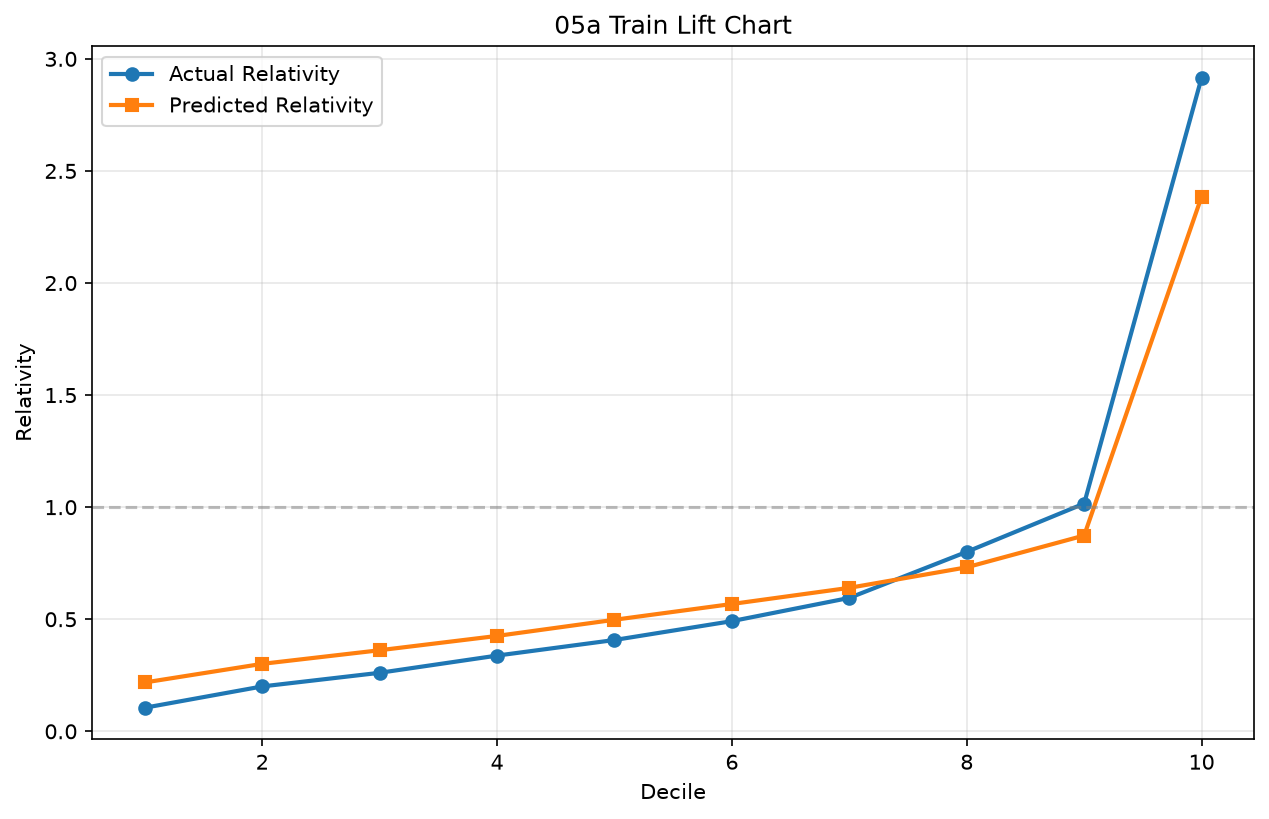


Train decile summary:
 decile        act       pred  act_rel  pred_rel
      1  21.618889  44.800185 0.105164  0.217929
      2  41.163135  61.870396 0.200237  0.300967
      3  53.667403  74.360219 0.261063  0.361723
      4  69.447914  87.479522 0.337827  0.425541
      5  83.748507 102.298083 0.407392  0.497626
      6 101.044874 116.776163 0.491530  0.568054
      7 122.358070 131.591884 0.595207  0.640125
      8 164.592827 150.422016 0.800657  0.731723
      9 208.905815 179.583874 1.016216  0.873580
     10 599.416733 490.311766 2.915845  2.385107


In [13]:
# Train lift chart
print(f'\n* Creating train lift chart...')
fig_train, table_train = create_lift_chart(
    train_orig, 
    exposure,  # weight column for decile binning
    bins=10, 
    title='05a Train Lift Chart'
)

chart_file = f'{output_base}/results/05a_lift_train.png'
fig_train.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_train)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTrain decile summary:')
print(table_train[['decile', 'act', 'pred', 'act_rel', 'pred_rel']].to_string(index=False))


* Creating test lift chart...
  [STEP 1] Creating column list...
  [STEP 1] Done in 0.000s
  [STEP 2] Extracting 5 columns from 7,483,698 rows...
  [STEP 2] Done in 0.036s
  [STEP 3a] Sorting by prediction (this may take 1-2 min for 2.7M rows)...


  [STEP 3a] sort_values done in 0.8s
  [STEP 3b] Resetting index...
  [STEP 3b] Done in 0.000s
  [STEP 4] Calculating cumulative weight...
  [STEP 4] Done in 0.040s
  [STEP 5] Aggregating by decile...


  [STEP 5] Done in 0.228s
  Creating plot...
  Plot created in 0.0s
  TOTAL TIME: 1.1s
  Saved: output/car_liab/v1/results/05a_lift_test.png


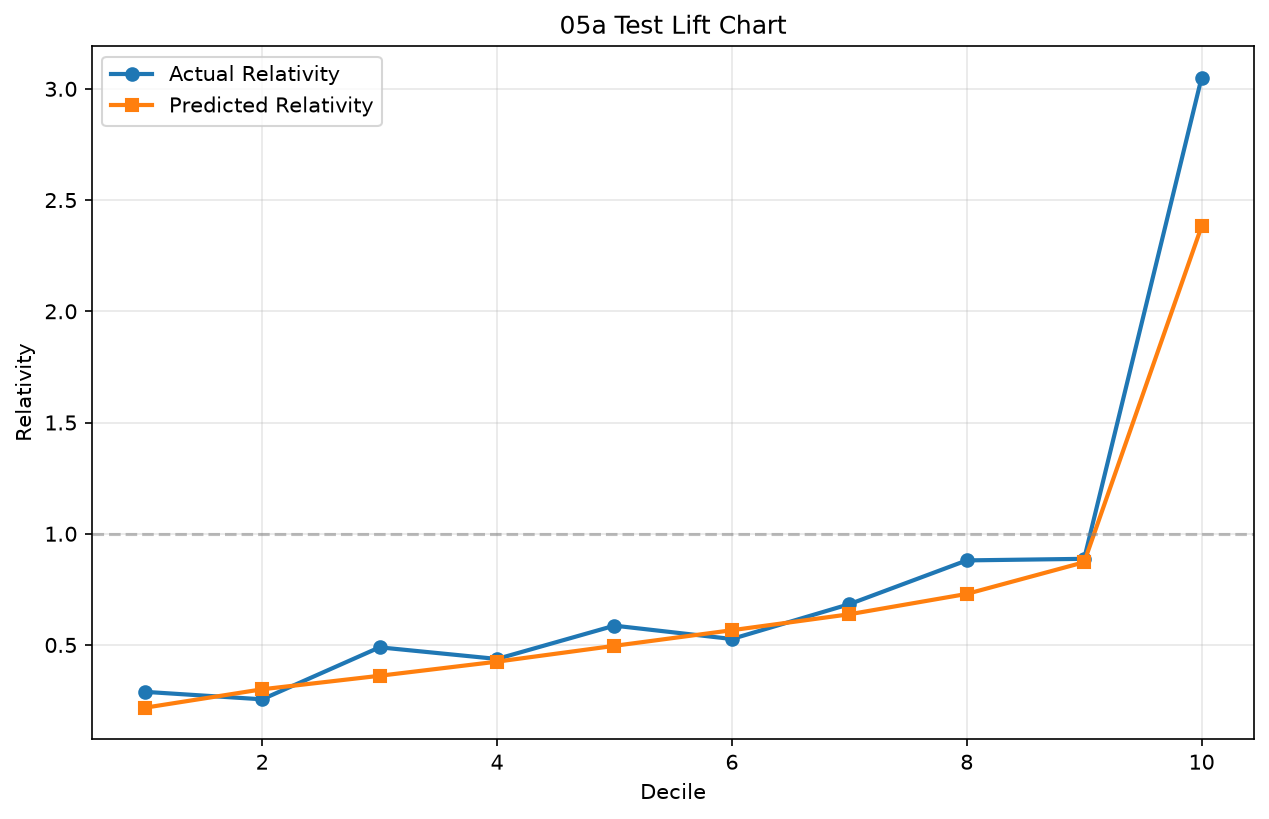


Test decile summary:
 decile        act       pred  act_rel  pred_rel
      1  59.642801  44.902013 0.289373  0.217854
      2  52.705432  62.004468 0.255714  0.300831
      3 100.889695  74.533215 0.489493  0.361618
      4  90.106816  87.608977 0.437177  0.425058
      5 120.960290 102.283209 0.586871  0.496254
      6 108.589358 116.731581 0.526850  0.566354
      7 140.856679 131.500406 0.683404  0.638009
      8 181.430049 150.359211 0.880256  0.729508
      9 182.877571 179.737112 0.887279  0.872042
     10 628.627773 490.860055 3.049954  2.381538


In [14]:
# Test lift chart
print(f'\n* Creating test lift chart...')
fig_test, table_test = create_lift_chart(
    test_orig, 
    exposure,  # weight column for decile binning
    bins=10, 
    title='05a Test Lift Chart'
)

chart_file = f'{output_base}/results/05a_lift_test.png'
fig_test.savefig(chart_file, dpi=150, bbox_inches='tight')
plt.close(fig_test)
print(f'  Saved: {chart_file}')

display(Image(chart_file))
print('\nTest decile summary:')
print(table_test[['decile', 'act', 'pred', 'act_rel', 'pred_rel']].to_string(index=False))

In [15]:
# Calculate actuarial metrics
print(f'\n* Calculating actuarial metrics...')

fit_train = compute_fit_quality(y_train, pred_train, w_train)
fit_test = compute_fit_quality(y_test, pred_test, w_test)
power_train = compute_model_power(y_train, pred_train, w_train)
power_test = compute_model_power(y_test, pred_test, w_test)

print(f'\n* Actuarial Metrics:')
print(f'  Train:')
print(f'    Fit Quality:  {fit_train:.4f}')
print(f'    Model Power:  {power_train:.4f}')
print(f'  Test:')
print(f'    Fit Quality:  {fit_test:.4f}')
print(f'    Model Power:  {power_test:.4f}')


* Calculating actuarial metrics...



* Actuarial Metrics:
  Train:
    Fit Quality:  0.6810
    Model Power:  0.4358
  Test:
    Fit Quality:  0.8564
    Model Power:  0.4357


In [16]:
# Save model
os.makedirs(f"{output_base}/models", exist_ok=True)
model_file = f"{output_base}/models/05a_model_initial.json"
model.get_booster().save_model(model_file)
print(f"\n* Saved model: {model_file}")


* Saved model: output/car_liab/v1/models/05a_model_initial.json


In [17]:
# Save predictions
os.makedirs(f"{output_base}/results", exist_ok=True)

pd.DataFrame({
    "actual": y_train,
    "pred": pred_train,
    "exposure": w_train
}).to_parquet(f"{output_base}/results/05a_predictions_train.parquet", index=True)

pd.DataFrame({
    "actual": y_test,
    "pred": pred_test,
    "exposure": w_test
}).to_parquet(f"{output_base}/results/05a_predictions_test.parquet", index=True)

print(f"* Saved predictions")

* Saved predictions


In [18]:
# Save metrics
metrics = {
    "stage": "05a_initial",
    "train": {"mae": float(mae_train), "rmse": float(rmse_train)},
    "test": {"mae": float(mae_test), "rmse": float(rmse_test)},
    "best_iteration": int(model.best_iteration),
    "n_features": int(X_train.shape[1]),
    "monotone_constraints_applied": monotone_constraints is not None,
    "base_margin_applied": base_margin_train is not None
}

with open(f"{output_base}/results/05a_metrics.yaml", "w") as f:
    yaml.dump(metrics, f)

print(f"* Saved metrics")

* Saved metrics


In [19]:
print("\n########################################")
print("# STAGE 05a: COMPLETE")
print("########################################")


########################################
# STAGE 05a: COMPLETE
########################################
